# goals
* explore the mismatch between lensed, RP and NP waveforms
* explore the conditions for indistinguishable waveforms

# import modules

In [6]:
import sys

sys.path.insert(0, "../")
from modules.functions_v2 import *
from modules.plot_utils import *

In [7]:
# DRY plotting helpers
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction


def make_frequency_array(f_min, f_cut, delta_f=None, npoints=None):
    if npoints is not None:
        return np.linspace(f_min, f_cut, int(npoints))
    if delta_f is None:
        raise ValueError("Provide either delta_f or npoints")
    return np.arange(f_min, f_cut, delta_f)


def compute_phase(strain):
    return np.unwrap(np.angle(strain))


def _format_angle_pi(angle, max_den=24):
    r"""Return a TeX-ready string for angle in radians as multiple of \pi.
    Examples: 0 -> 0, \pi/3 -> '$\pi/3$', 2\pi/3 -> '$2\pi/3$', \pi -> '$\pi$', 3\pi/2 -> '$3\pi/2$'.
    Returns a string already wrapped in math mode $...$.
    """
    x = angle / np.pi
    if np.isclose(x, 0.0, atol=1e-10):
        return "0"
    frac = Fraction(x).limit_denominator(max_den)
    n, d = frac.numerator, frac.denominator
    sign = "-" if n < 0 else ""
    n_abs = abs(n)
    if d == 1:
        # integer multiple
        return rf"${sign}\pi$" if n_abs == 1 else rf"${sign}{n_abs}\pi$"
    # general fraction
    return rf"${sign}\pi/{d}$" if n_abs == 1 else rf"${sign}{n_abs}\pi/{d}$"


def customize_2x2_axes_ratio(axes):
    """Like modules.plot_utils.customize_2x2_axes but for ratio panels:
    - Do NOT use log yscale
    - Do NOT force the same y-limits across rows
    Keeps legends, grids, labels, and tick sizes consistent.
    """
    # top panel
    axes[0, 0].legend(
        bbox_to_anchor=(2.3, 1), loc="upper left", borderaxespad=0.0, fontsize=20
    )
    axes[0, 0].tick_params(axis="both", which="major", labelsize=18)
    axes[0, 0].grid()
    axes[0, 1].tick_params(axis="both", which="major", labelsize=18)
    axes[0, 1].grid()

    # bottom panel
    axes[1, 0].legend(
        bbox_to_anchor=(2.3, 1), loc="upper left", borderaxespad=0.0, fontsize=20
    )
    axes[1, 0].set_xlabel("f (Hz)", fontsize=24)
    axes[1, 0].tick_params(axis="both", which="major", labelsize=18)
    axes[1, 0].grid()
    axes[1, 1].set_xlabel("f (Hz)", fontsize=24)
    axes[1, 1].tick_params(axis="both", which="major", labelsize=18)
    axes[1, 1].grid()

    # Ensure linear y-scale for amplitude panels and autoscale independently
    for ax in (axes[0, 0], axes[1, 0]):
        ax.set_yscale("linear")
        ax.relim()
        ax.autoscale_view()


def customize_3x2_axes_abs(axes):
    """Customizer for 3x2 figures (abs mode):
    - Log scale on amplitude panels (col 0)
    - Legends on each amplitude row
    - Grids and tick sizes consistent
    """
    for r in range(3):
        axes[r, 0].legend(
            bbox_to_anchor=(2.3, 1), loc="upper left", borderaxespad=0.0, fontsize=20
        )
        axes[r, 0].tick_params(axis="both", which="major", labelsize=18)
        axes[r, 0].grid()
        axes[r, 0].set_yscale("log")
        axes[r, 1].tick_params(axis="both", which="major", labelsize=18)
        axes[r, 1].grid()
    # x labels on bottom row
    axes[2, 0].set_xlabel("f (Hz)", fontsize=24)
    axes[2, 1].set_xlabel("f (Hz)", fontsize=24)


def customize_3x2_axes_ratio(axes):
    """Customizer for 3x2 figures (ratio mode):
    - Linear y-scale on amplitude panels (col 0)
    - Legends on each amplitude row
    - Grids and tick sizes consistent
    """
    for r in range(3):
        axes[r, 0].legend(
            bbox_to_anchor=(2.3, 1), loc="upper left", borderaxespad=0.0, fontsize=20
        )
        axes[r, 0].tick_params(axis="both", which="major", labelsize=18)
        axes[r, 0].grid()
        axes[r, 0].set_yscale("linear")
        axes[r, 1].tick_params(axis="both", which="major", labelsize=18)
        axes[r, 1].grid()
    # x labels on bottom row
    axes[2, 0].set_xlabel("f (Hz)", fontsize=24)
    axes[2, 1].set_xlabel("f (Hz)", fontsize=24)


def plot_lensing_figure(
    lens_params_base,
    td_arr,
    def_y,
    I_arr,
    def_td,
    *,
    amplitude_mode="abs",
    line_styles=None,
    baseline_color="darkorange",
    f_min=20,
    npoints=10000,
    save_path=None,
    bbox_inches="tight",
    pad_inches=0.02,
):
    """Plot 2x2 lensing panels varying (top) time delay via MLz and (bottom) I via y.

    amplitude_mode: "abs" for |h| vs UL, "ratio" for (|h_L|/|h_UL|)-1
    save_path: optional file path to save the figure; format inferred by extension.
    Returns (fig, axes).
    """
    if line_styles is None:
        line_styles = ["-", "--", ":"]
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
    fig.subplots_adjust(wspace=0.25)

    # --- Top row: vary time delay (via MLz) at fixed impact y ---
    for i, td in enumerate(np.atleast_1d(td_arr)):
        lens_params = lens_params_base.copy()
        MLz = get_MLz_from_td(td, def_y)
        lens_params["MLz"] = MLz * solar_mass
        lens_inst = LensingGeo(lens_params)
        f_cut = lens_inst.f_cut()
        f_arr = make_frequency_array(f_min, f_cut, npoints=npoints)
        unlensed_strain = lens_inst.hI(f_arr)
        lensed_strain = lens_inst.strain(f_arr)
        phase_diff = compute_phase(lensed_strain) - compute_phase(unlensed_strain)
        if amplitude_mode == "abs":
            yvals = np.abs(lensed_strain)
            if i == 0:
                axes[0, 0].plot(
                    f_arr,
                    np.abs(unlensed_strain),
                    ls="-",
                    color=baseline_color,
                    label="Unlensed",
                )
                axes[0, 1].plot(
                    f_arr,
                    np.zeros_like(f_arr),
                    ls="-",
                    color=baseline_color,
                    label="Unlensed",
                )
        else:
            yvals = np.abs(lensed_strain) / np.abs(unlensed_strain) - 1
            if i == 0:
                axes[0, 0].plot(
                    f_arr,
                    np.zeros_like(f_arr),
                    ls="-",
                    color=baseline_color,
                    label="Unlensed",
                )
                axes[0, 1].plot(
                    f_arr,
                    np.zeros_like(f_arr),
                    ls="-",
                    color=baseline_color,
                    label="Unlensed",
                )
        Delta_td = lens_inst.td()
        axes[0, 0].plot(
            f_arr,
            yvals,
            ls=line_styles[i % len(line_styles)],
            color="black",
            label=rf"$\Delta t_d$ = {Delta_td*1000:.2g} ms",
        )
        axes[0, 1].plot(
            f_arr,
            phase_diff,
            ls=line_styles[i % len(line_styles)],
            color="black",
            label=rf"$\Delta t_d$ = {Delta_td*1000:.2g} ms",
        )

    # --- Bottom row: vary I (via y) at fixed time delay def_td ---
    for i, I in enumerate(np.atleast_1d(I_arr)):
        lens_params = lens_params_base.copy()
        y = get_y_from_I(I)
        MLz = get_MLz_from_td(def_td, y)
        lens_params["y"] = y
        lens_params["MLz"] = MLz * solar_mass
        lens_inst = LensingGeo(lens_params)
        f_cut = lens_inst.f_cut()
        f_arr = make_frequency_array(f_min, f_cut, npoints=npoints)
        unlensed_strain = lens_inst.hI(f_arr)
        lensed_strain = lens_inst.strain(f_arr)
        phase_diff = compute_phase(lensed_strain) - compute_phase(unlensed_strain)
        if amplitude_mode == "abs":
            yvals = np.abs(lensed_strain)
            if i == 0:
                axes[1, 0].plot(
                    f_arr,
                    np.abs(unlensed_strain),
                    ls="-",
                    color=baseline_color,
                    label="Unlensed",
                )
                axes[1, 1].plot(
                    f_arr,
                    np.zeros_like(f_arr),
                    ls="-",
                    color=baseline_color,
                    label="Unlensed",
                )
        else:
            yvals = np.abs(lensed_strain) / np.abs(unlensed_strain) - 1
            if i == 0:
                axes[1, 0].plot(
                    f_arr,
                    np.zeros_like(f_arr),
                    ls="-",
                    color=baseline_color,
                    label="Unlensed",
                )
                axes[1, 1].plot(
                    f_arr,
                    np.zeros_like(f_arr),
                    ls="-",
                    color=baseline_color,
                    label="Unlensed",
                )
        I_val = lens_inst.I()
        axes[1, 0].plot(
            f_arr,
            yvals,
            ls=line_styles[i % len(line_styles)],
            color="black",
            label=rf"$I$ = {I_val:.2g}",
        )
        axes[1, 1].plot(
            f_arr,
            phase_diff,
            ls=line_styles[i % len(line_styles)],
            color="black",
            label=rf"$I$ = {I_val:.2g}",
        )

    # Labels and styling
    if amplitude_mode == "abs":
        fig.text(0.06, 0.5, r"$|\~{h}|$", va="center", rotation="vertical", fontsize=24)
        fig.text(
            0.49,
            0.5,
            r"$\Phi_L - \Phi_{UL}$ (rad)",
            va="center",
            rotation="vertical",
            fontsize=24,
        )
        customize_2x2_axes(axes)
    else:
        fig.text(
            0.06,
            0.5,
            r"$\left( B_L/|B_{UL} \right) - 1$",
            va="center",
            rotation="vertical",
            fontsize=24,
        )
        fig.text(
            0.49,
            0.5,
            r"$\Phi_L - \Phi_{UL}$ (rad)",
            va="center",
            rotation="vertical",
            fontsize=24,
        )
        customize_2x2_axes_ratio(axes)

    # Optional save (format inferred from extension)
    if save_path:
        fig.savefig(save_path, bbox_inches=bbox_inches, pad_inches=pad_inches)
    return fig, axes


def plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    *,
    theta_vals,
    omega_vals,
    gamma_vals=(0.0, np.pi / 3, 2 * np.pi / 3),
    fixed_theta=4,
    fixed_omega=2,
    amplitude_mode="abs",
    line_styles=None,
    baseline_color="darkorange",
    f_min=20,
    delta_f=0.05,
    save_path=None,
    bbox_inches="tight",
    pad_inches=0.02,
):
    """Plot 3x2 precessing panels:
    - Row 0: vary omega_tilde (fixed theta)
    - Row 1: vary theta_tilde (fixed omega)
    - Row 2: vary gamma_P (fixed theta and omega)
    amplitude_mode: "abs" or "ratio".
    save_path: optional file path to save the figure; format inferred by extension.
    Returns (fig, axes).
    """
    if line_styles is None:
        line_styles = ["-", "--", ":"]
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 18))
    fig.subplots_adjust(wspace=0.25)

    # Helper to run a sweep
    def sweep(row, vary_key, values, fixed_items, label_tex):
        for i, val in enumerate(values):
            RP_params = RP_params_1.copy()
            NP_params = NP_params_1.copy()
            # apply fixed
            for k, v in fixed_items.items():
                RP_params[k] = v
            RP_params[vary_key] = val
            RP_inst = Precessing(RP_params)
            f_cut = RP_inst.f_cut()
            f_arr = make_frequency_array(f_min, f_cut, delta_f=delta_f)
            RP_strain = RP_inst.strain(f_arr)
            NP_inst = Precessing(NP_params)
            NP_strain = NP_inst.strain(f_arr)
            phase_diff = compute_phase(RP_strain) - compute_phase(NP_strain)
            if amplitude_mode == "abs":
                yvals = np.abs(RP_strain)
                if i == 0:
                    axes[row, 0].plot(
                        f_arr,
                        np.abs(NP_strain),
                        label="NP",
                        color=baseline_color,
                        ls="-",
                    )
                    axes[row, 1].plot(
                        f_arr,
                        np.zeros_like(f_arr),
                        label="NP",
                        color=baseline_color,
                        ls="-",
                    )
            else:
                yvals = np.abs(RP_strain) / np.abs(NP_strain) - 1
                if i == 0:
                    axes[row, 0].plot(
                        f_arr,
                        np.zeros_like(f_arr),
                        label="NP",
                        color=baseline_color,
                        ls="-",
                    )
                    axes[row, 1].plot(
                        f_arr,
                        np.zeros_like(f_arr),
                        label="NP",
                        color=baseline_color,
                        ls="-",
                    )
            if vary_key == "gamma_P":
                gamma_tex = _format_angle_pi(val)
                label_str = r"$\gamma_P$ = " + gamma_tex
            else:
                label_str = f"{label_tex} = {val}"
            axes[row, 0].plot(
                f_arr,
                yvals,
                label=label_str,
                color="black",
                ls=line_styles[i % len(line_styles)],
            )
            axes[row, 1].plot(
                f_arr,
                phase_diff,
                label=label_str,
                color="black",
                ls=line_styles[i % len(line_styles)],
            )

    # Row order: omega, theta, gamma
    sweep(
        0,
        "omega_tilde",
        np.atleast_1d(omega_vals),
        {"theta_tilde": fixed_theta},
        r"$\tilde{\Omega}$",
    )
    sweep(
        1,
        "theta_tilde",
        np.atleast_1d(theta_vals),
        {"omega_tilde": fixed_omega},
        r"$\tilde{\theta}$",
    )
    sweep(
        2,
        "gamma_P",
        np.atleast_1d(gamma_vals),
        {"theta_tilde": fixed_theta, "omega_tilde": fixed_omega},
        r"$\gamma_P$",
    )

    # Labels and styling
    if amplitude_mode == "abs":
        fig.text(0.06, 0.5, r"$|\~{h}|$", va="center", rotation="vertical", fontsize=24)
        fig.text(
            0.49,
            0.5,
            r"$\Phi_{RP} - \Phi_{NP}$ (rad)",
            va="center",
            rotation="vertical",
            fontsize=24,
        )
        customize_3x2_axes_abs(axes)
    else:
        fig.text(
            0.06,
            0.5,
            r"$\left( B_{RP}/|B_{NP} \right) - 1$",
            va="center",
            rotation="vertical",
            fontsize=24,
        )
        fig.text(
            0.49,
            0.5,
            r"$\Phi_{RP} - \Phi_{NP}$ (rad)",
            va="center",
            rotation="vertical",
            fontsize=24,
        )
        customize_3x2_axes_ratio(axes)

    # Optional save (format inferred from extension)
    if save_path:
        fig.savefig(save_path, bbox_inches=bbox_inches, pad_inches=pad_inches)
    return fig, axes

# assign params

In [8]:
def_td = 0.03
def_I = 0.5
def_y = get_y_from_I(def_I)
def_MLz = get_MLz_from_td(def_td, def_y)
print(def_y, def_MLz)

lens_params_1["y"] = def_y
lens_params_1["MLz"] = def_MLz * solar_mass
lens_params_1, RP_params_1, NP_params_1 = set_to_location(
    loc_params["Taman"]["edgeon"], lens_params_1, RP_params_1, NP_params_1
)

0.34831069974900647 2174.547084457945


# lensing

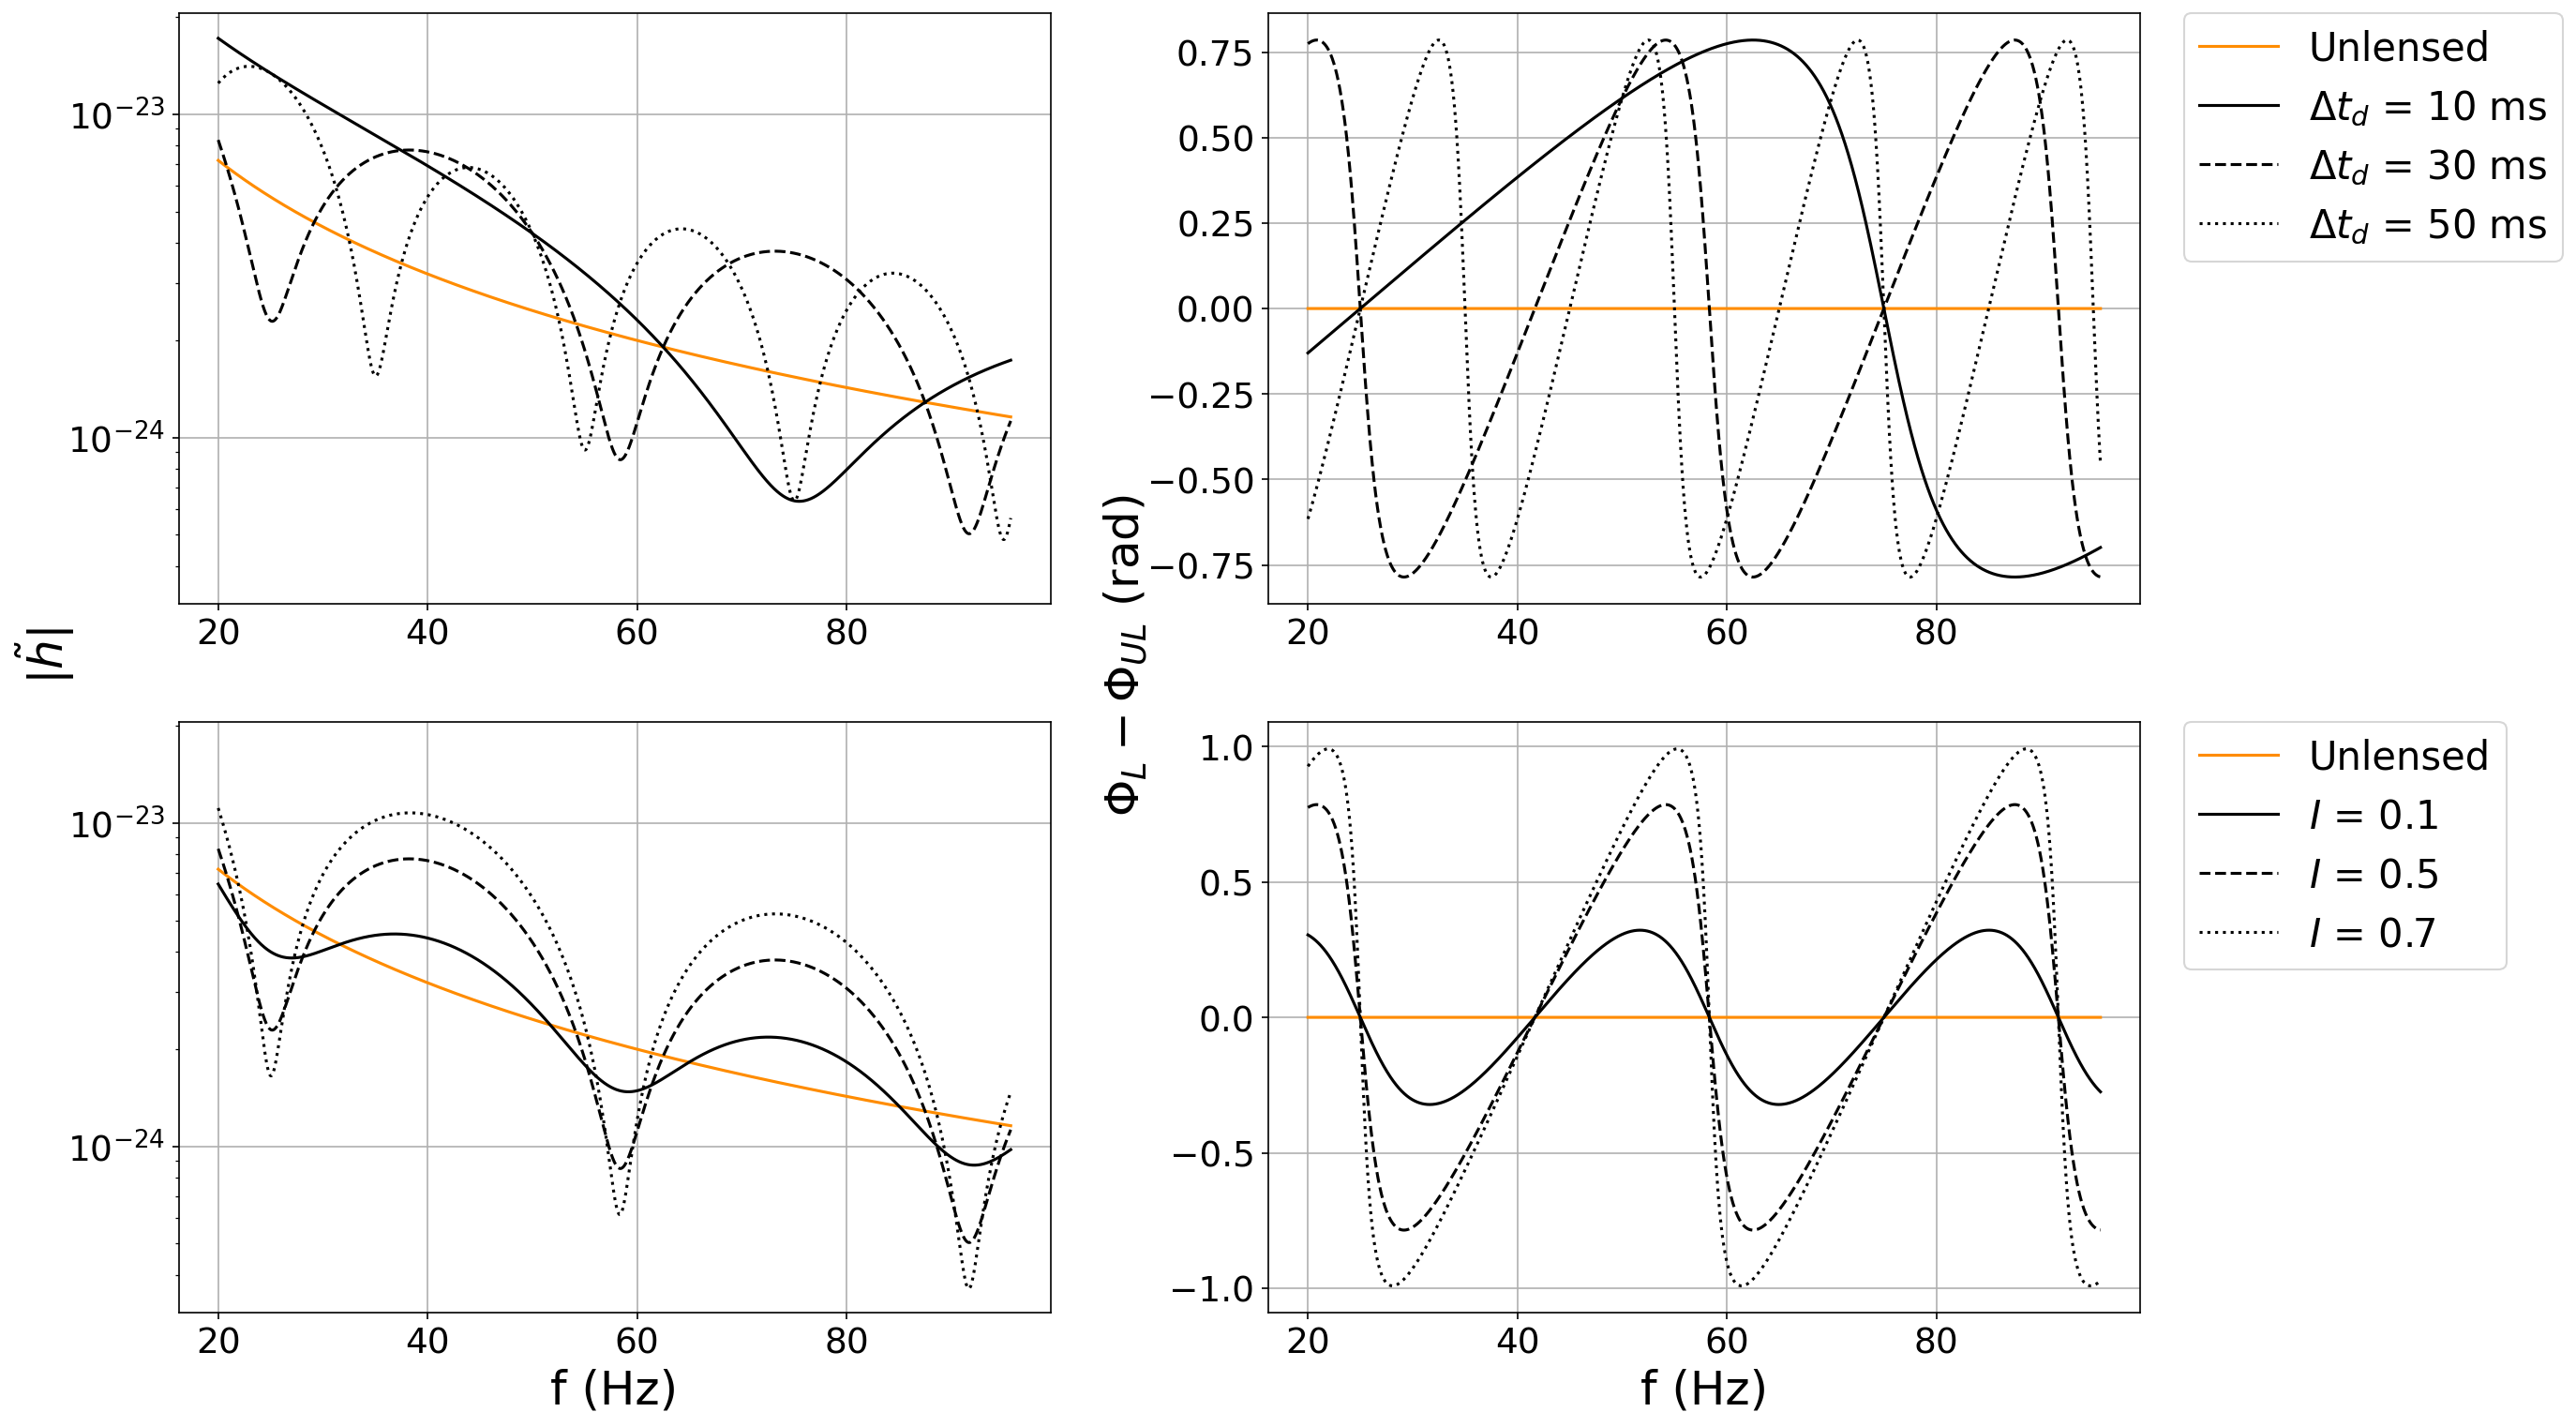

In [9]:
# Lensing: abs amplitude + phase via DRY helper
td_arr = np.array([0.01, 0.03, 0.05])
I_arr = np.array([0.1, 0.5, 0.7])
fig, axes = plot_lensing_figure(
    lens_params_1,
    td_arr=td_arr,
    def_y=def_y,
    I_arr=I_arr,
    def_td=def_td,
    amplitude_mode="abs",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=20,
    npoints=10000,
)

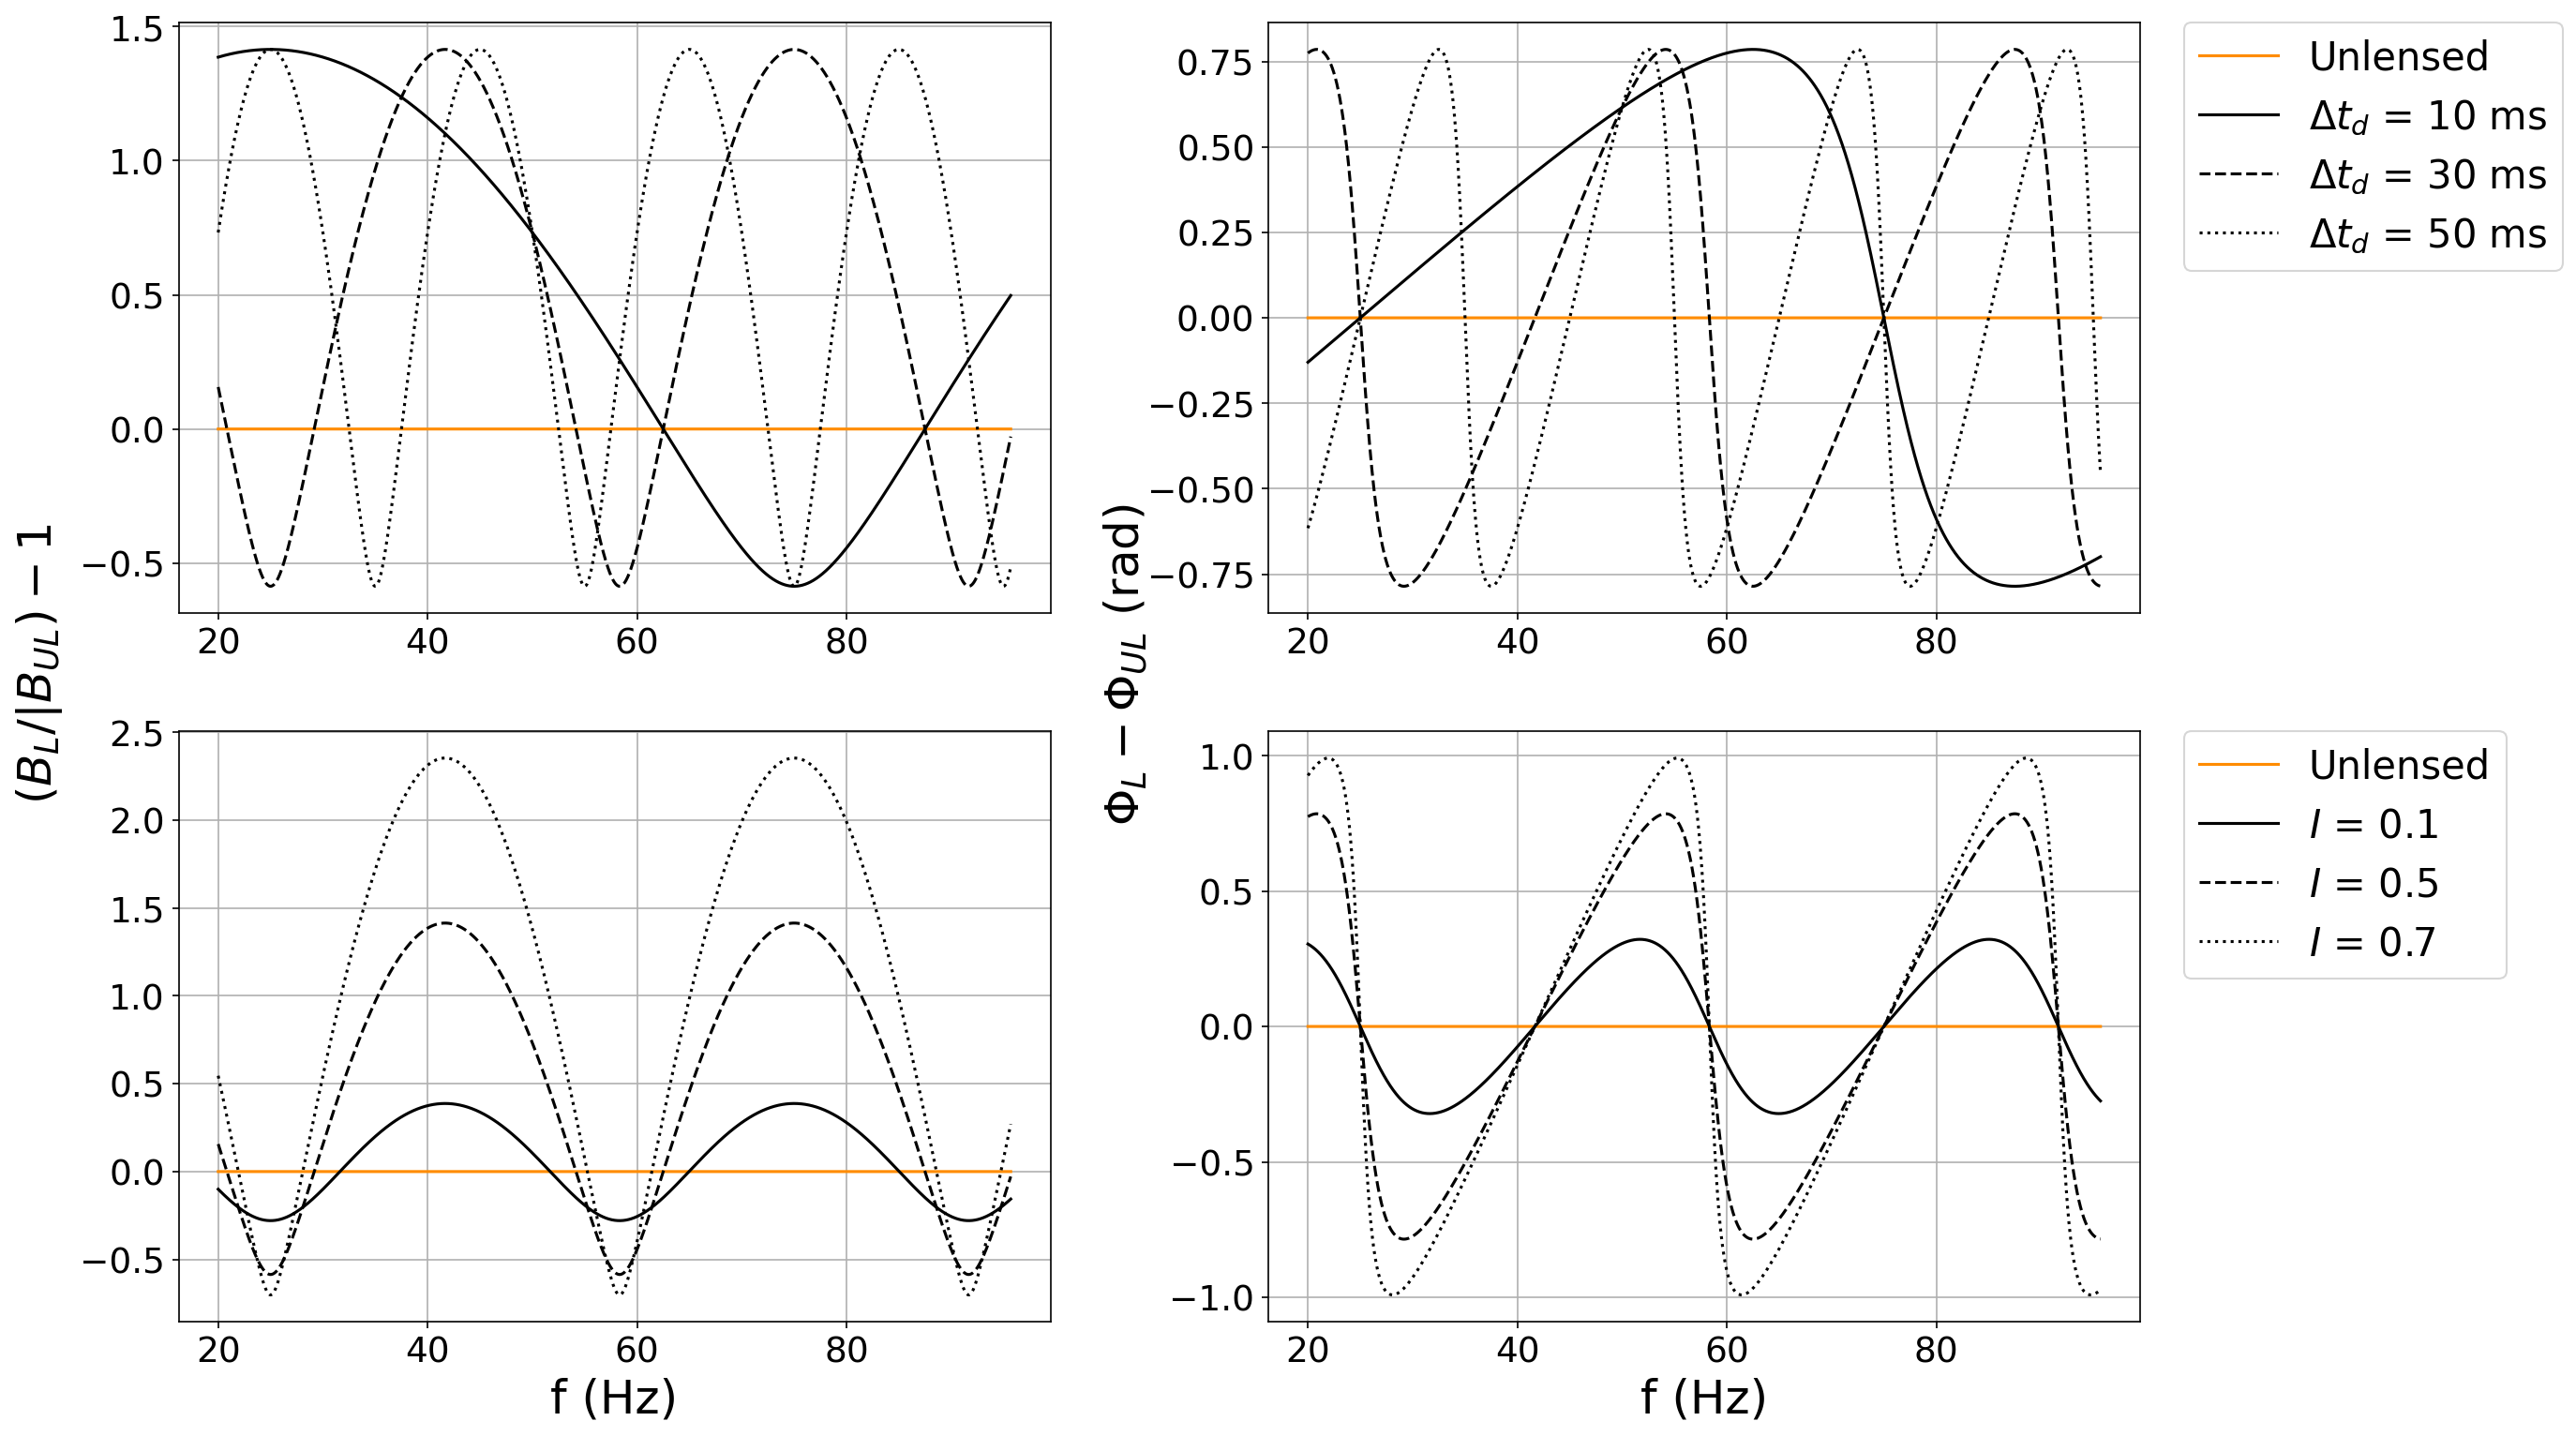

In [10]:
# Lensing: amplitude ratio + phase via DRY helper
td_arr = np.array([0.01, 0.03, 0.05])
I_arr = np.array([0.1, 0.5, 0.7])
fig, axes = plot_lensing_figure(
    lens_params_1,
    td_arr=td_arr,
    def_y=def_y,
    I_arr=I_arr,
    def_td=def_td,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=20,
    npoints=10000,
    save_path="../figures/waveforms_lensed.pdf",
)

# precessing

## random

system 3 in Taman's paper


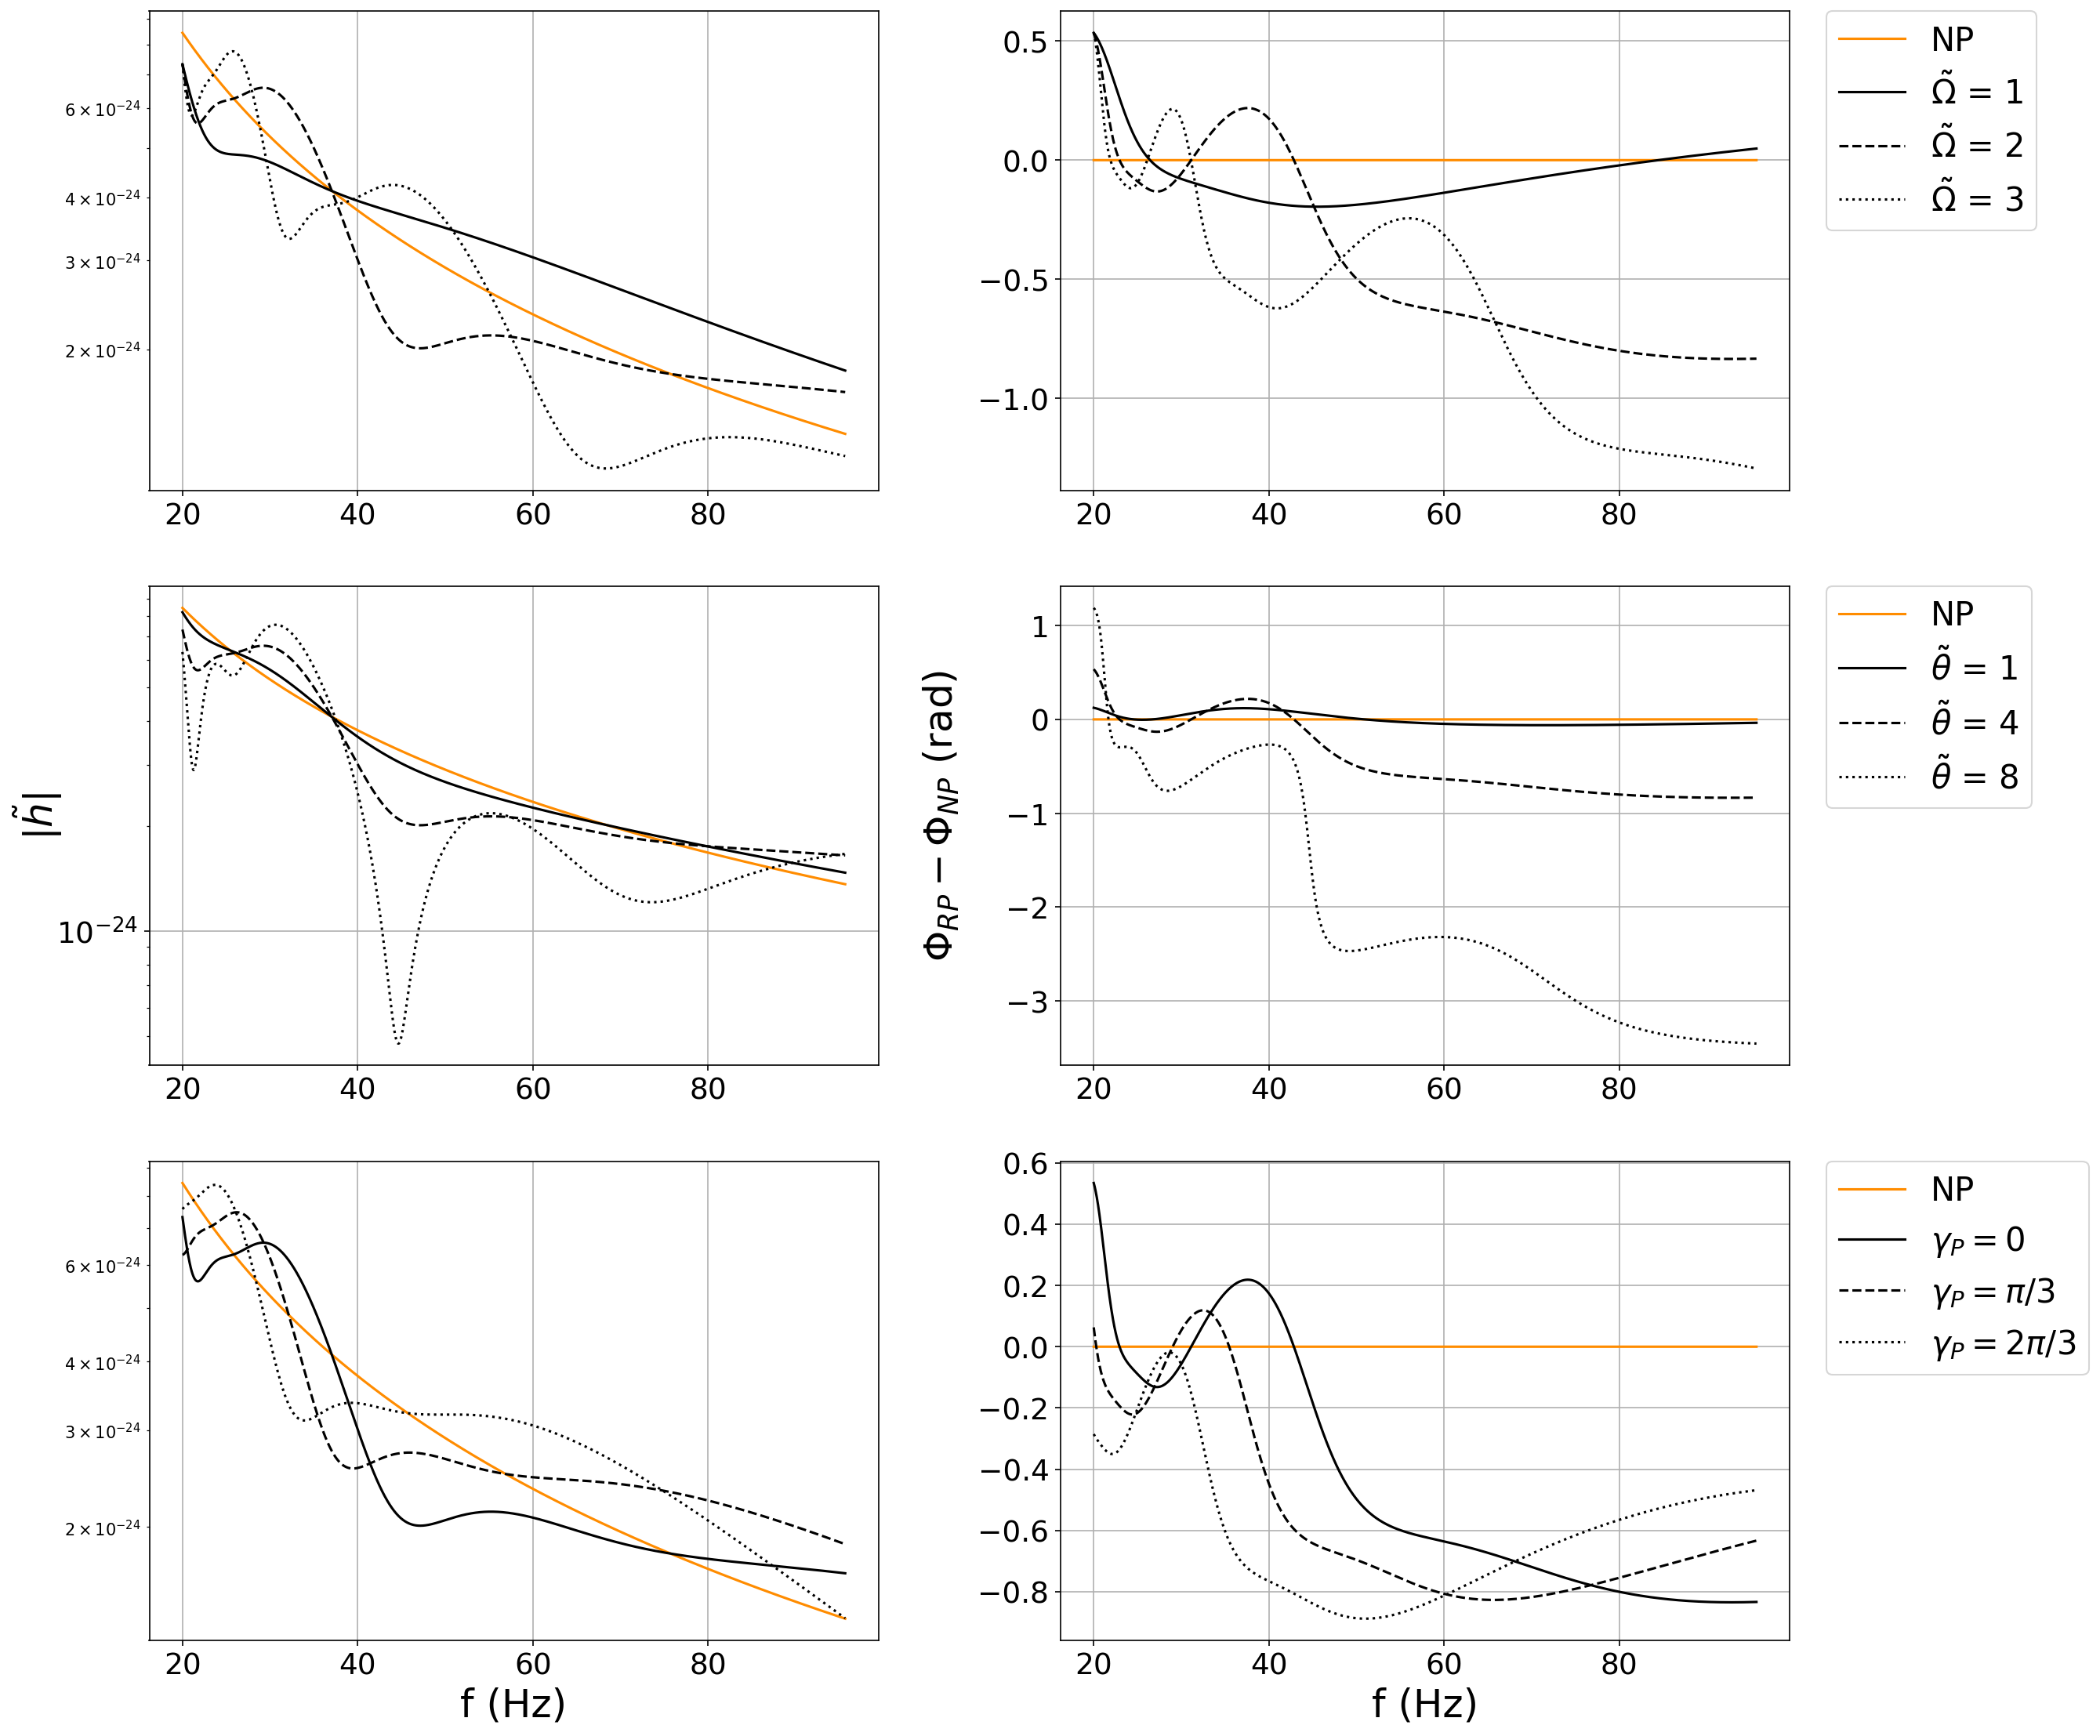

In [38]:
# Precessing (random): abs amplitude + phase via DRY helper
RP_params_1, NP_params_1 = set_to_location(
    loc_params["Taman"]["random"], RP_params_1, NP_params_1
)
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 4, 8]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="abs",
    line_styles=["-", "--", ":"],
    baseline_color="darkorange",
    f_min=20,
    delta_f=0.05,
)
print("system 3 in Taman's paper")

## edge-on

system 2 in Taman's paper


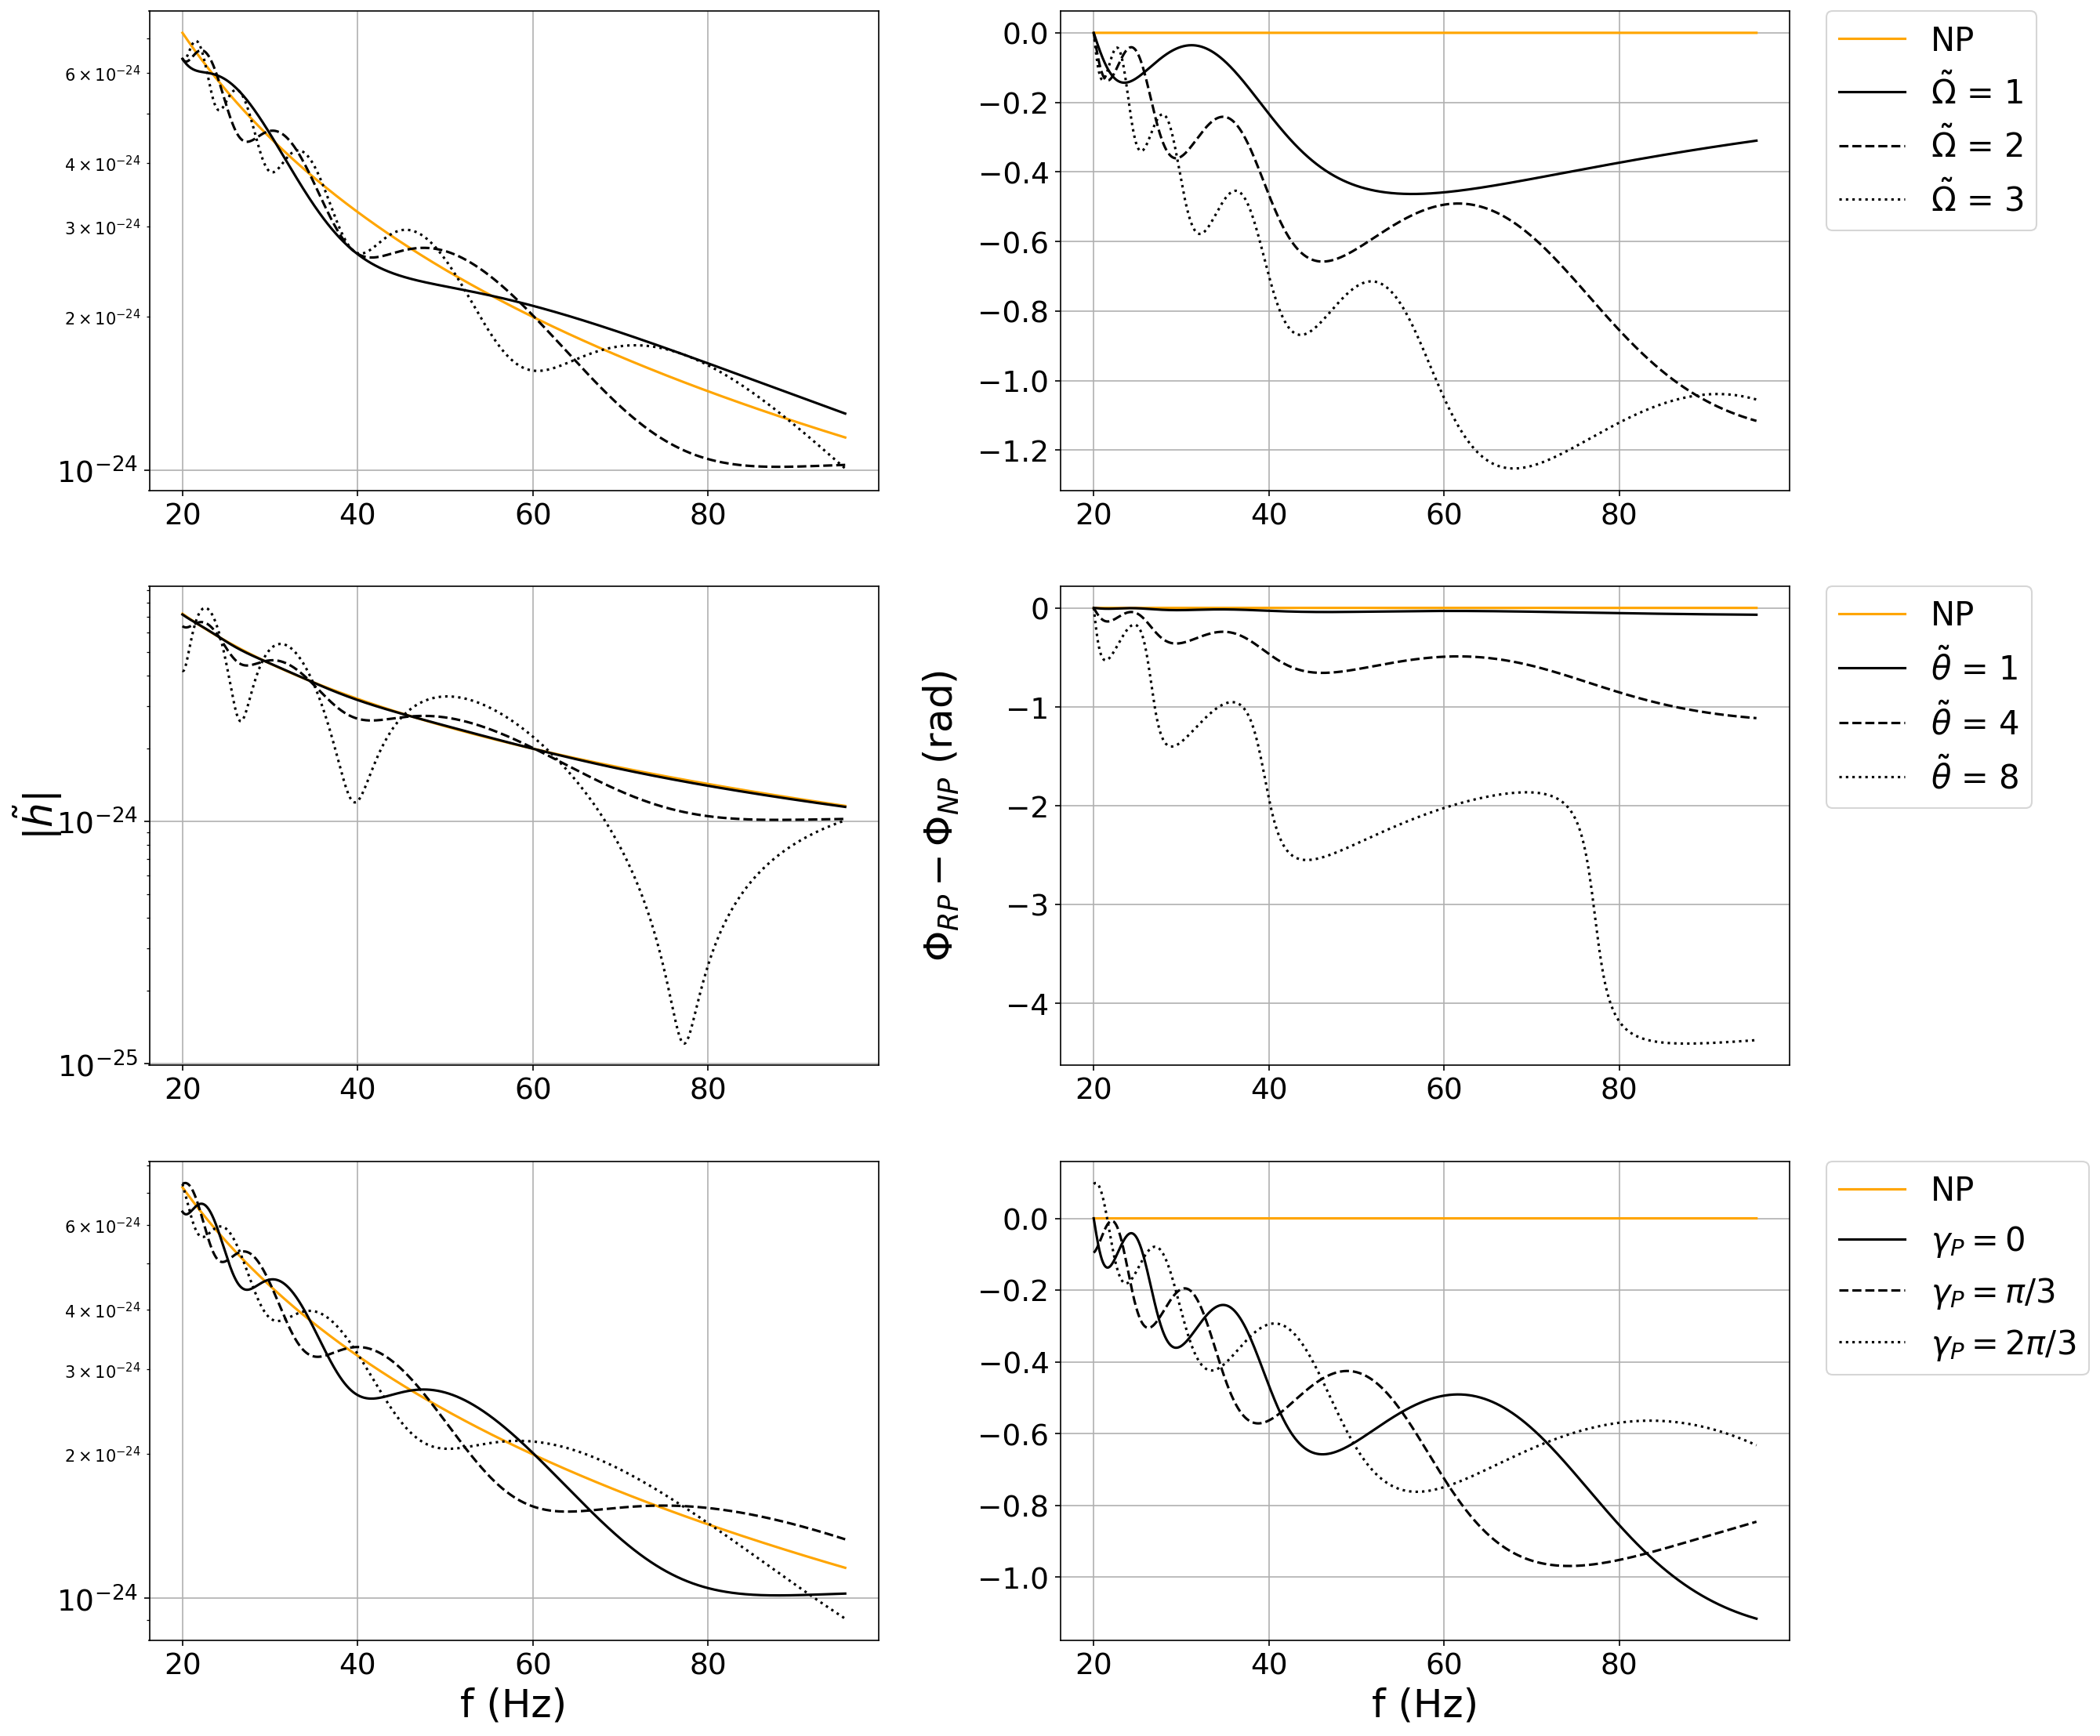

In [39]:
# Precessing (edge-on): abs amplitude + phase via DRY helper
RP_params_1, NP_params_1 = set_to_location(
    loc_params["Taman"]["edgeon"], RP_params_1, NP_params_1
)
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 4, 8]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="abs",
    line_styles=["-", "--", ":"],
    baseline_color="orange",
    f_min=20,
    delta_f=0.05,
)
print("system 2 in Taman's paper")

system 2 in Taman's paper


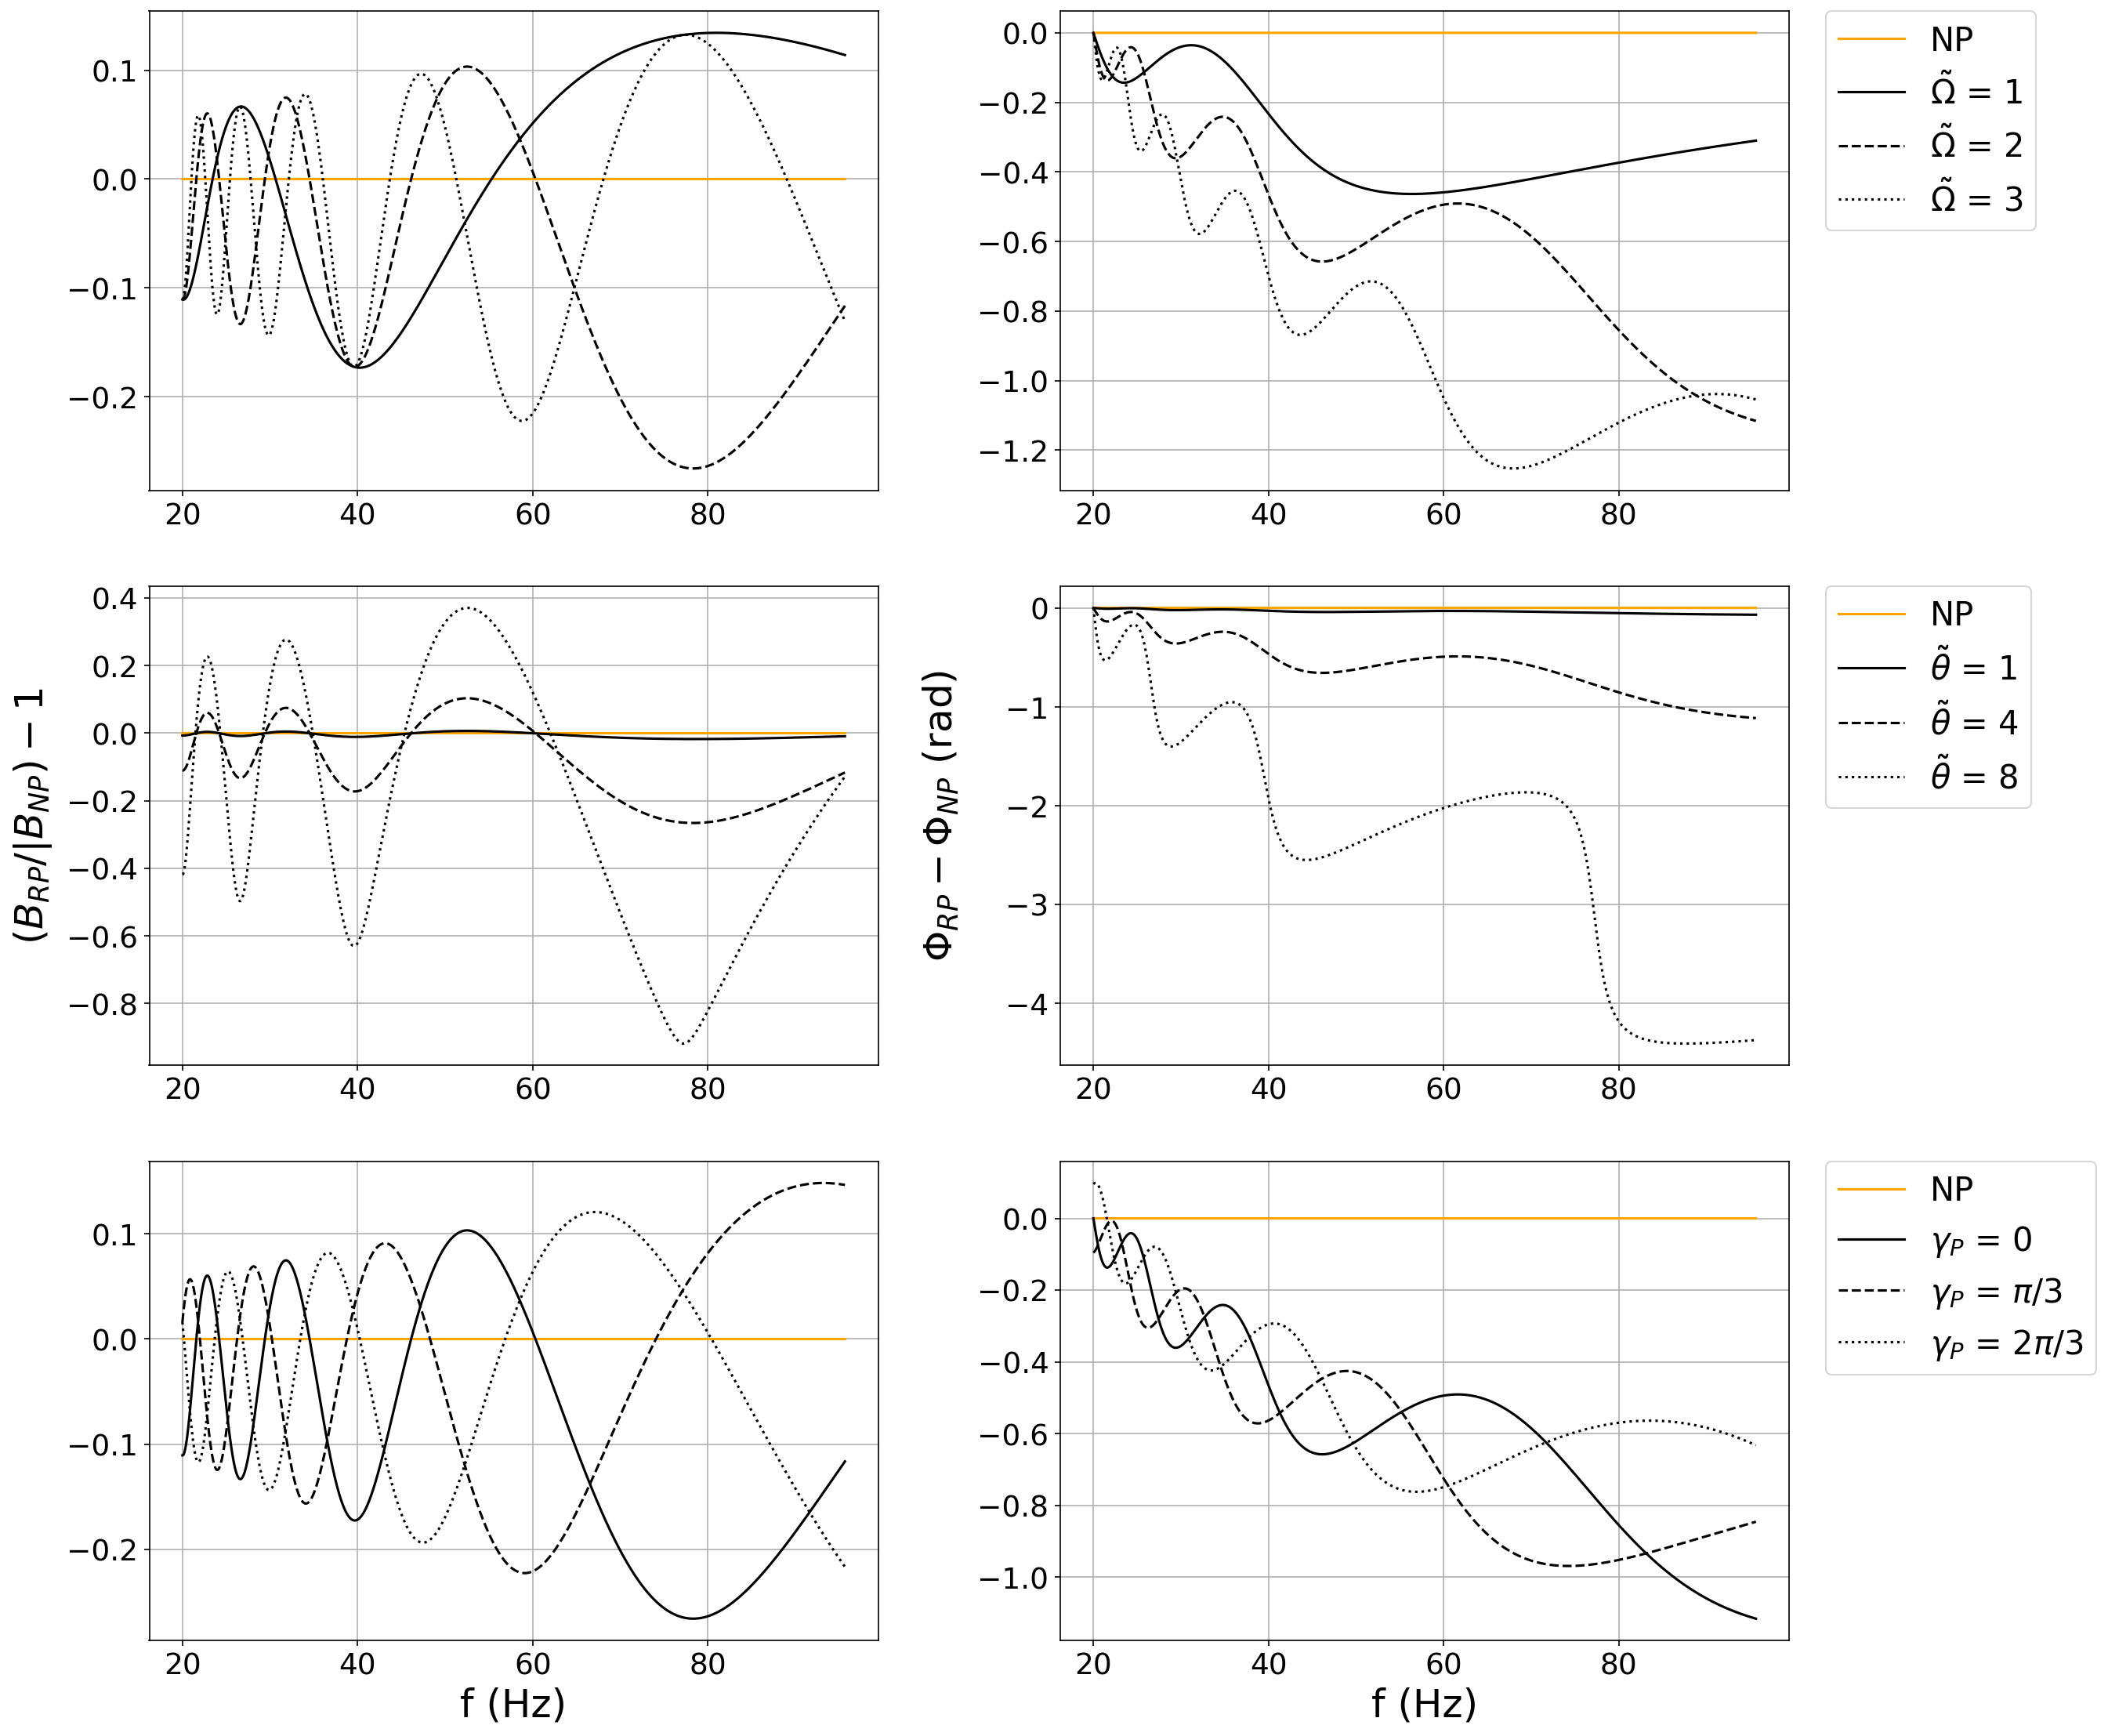

In [5]:
# Precessing (edge-on): amplitude ratio + phase via DRY helper
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 4, 8]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    baseline_color="orange",
    f_min=20,
    delta_f=0.05,
    save_path="../figures/waveforms_RP_sys2.pdf",
)
print("system 2 in Taman's paper")

## face-on

system 1 in Taman's paper


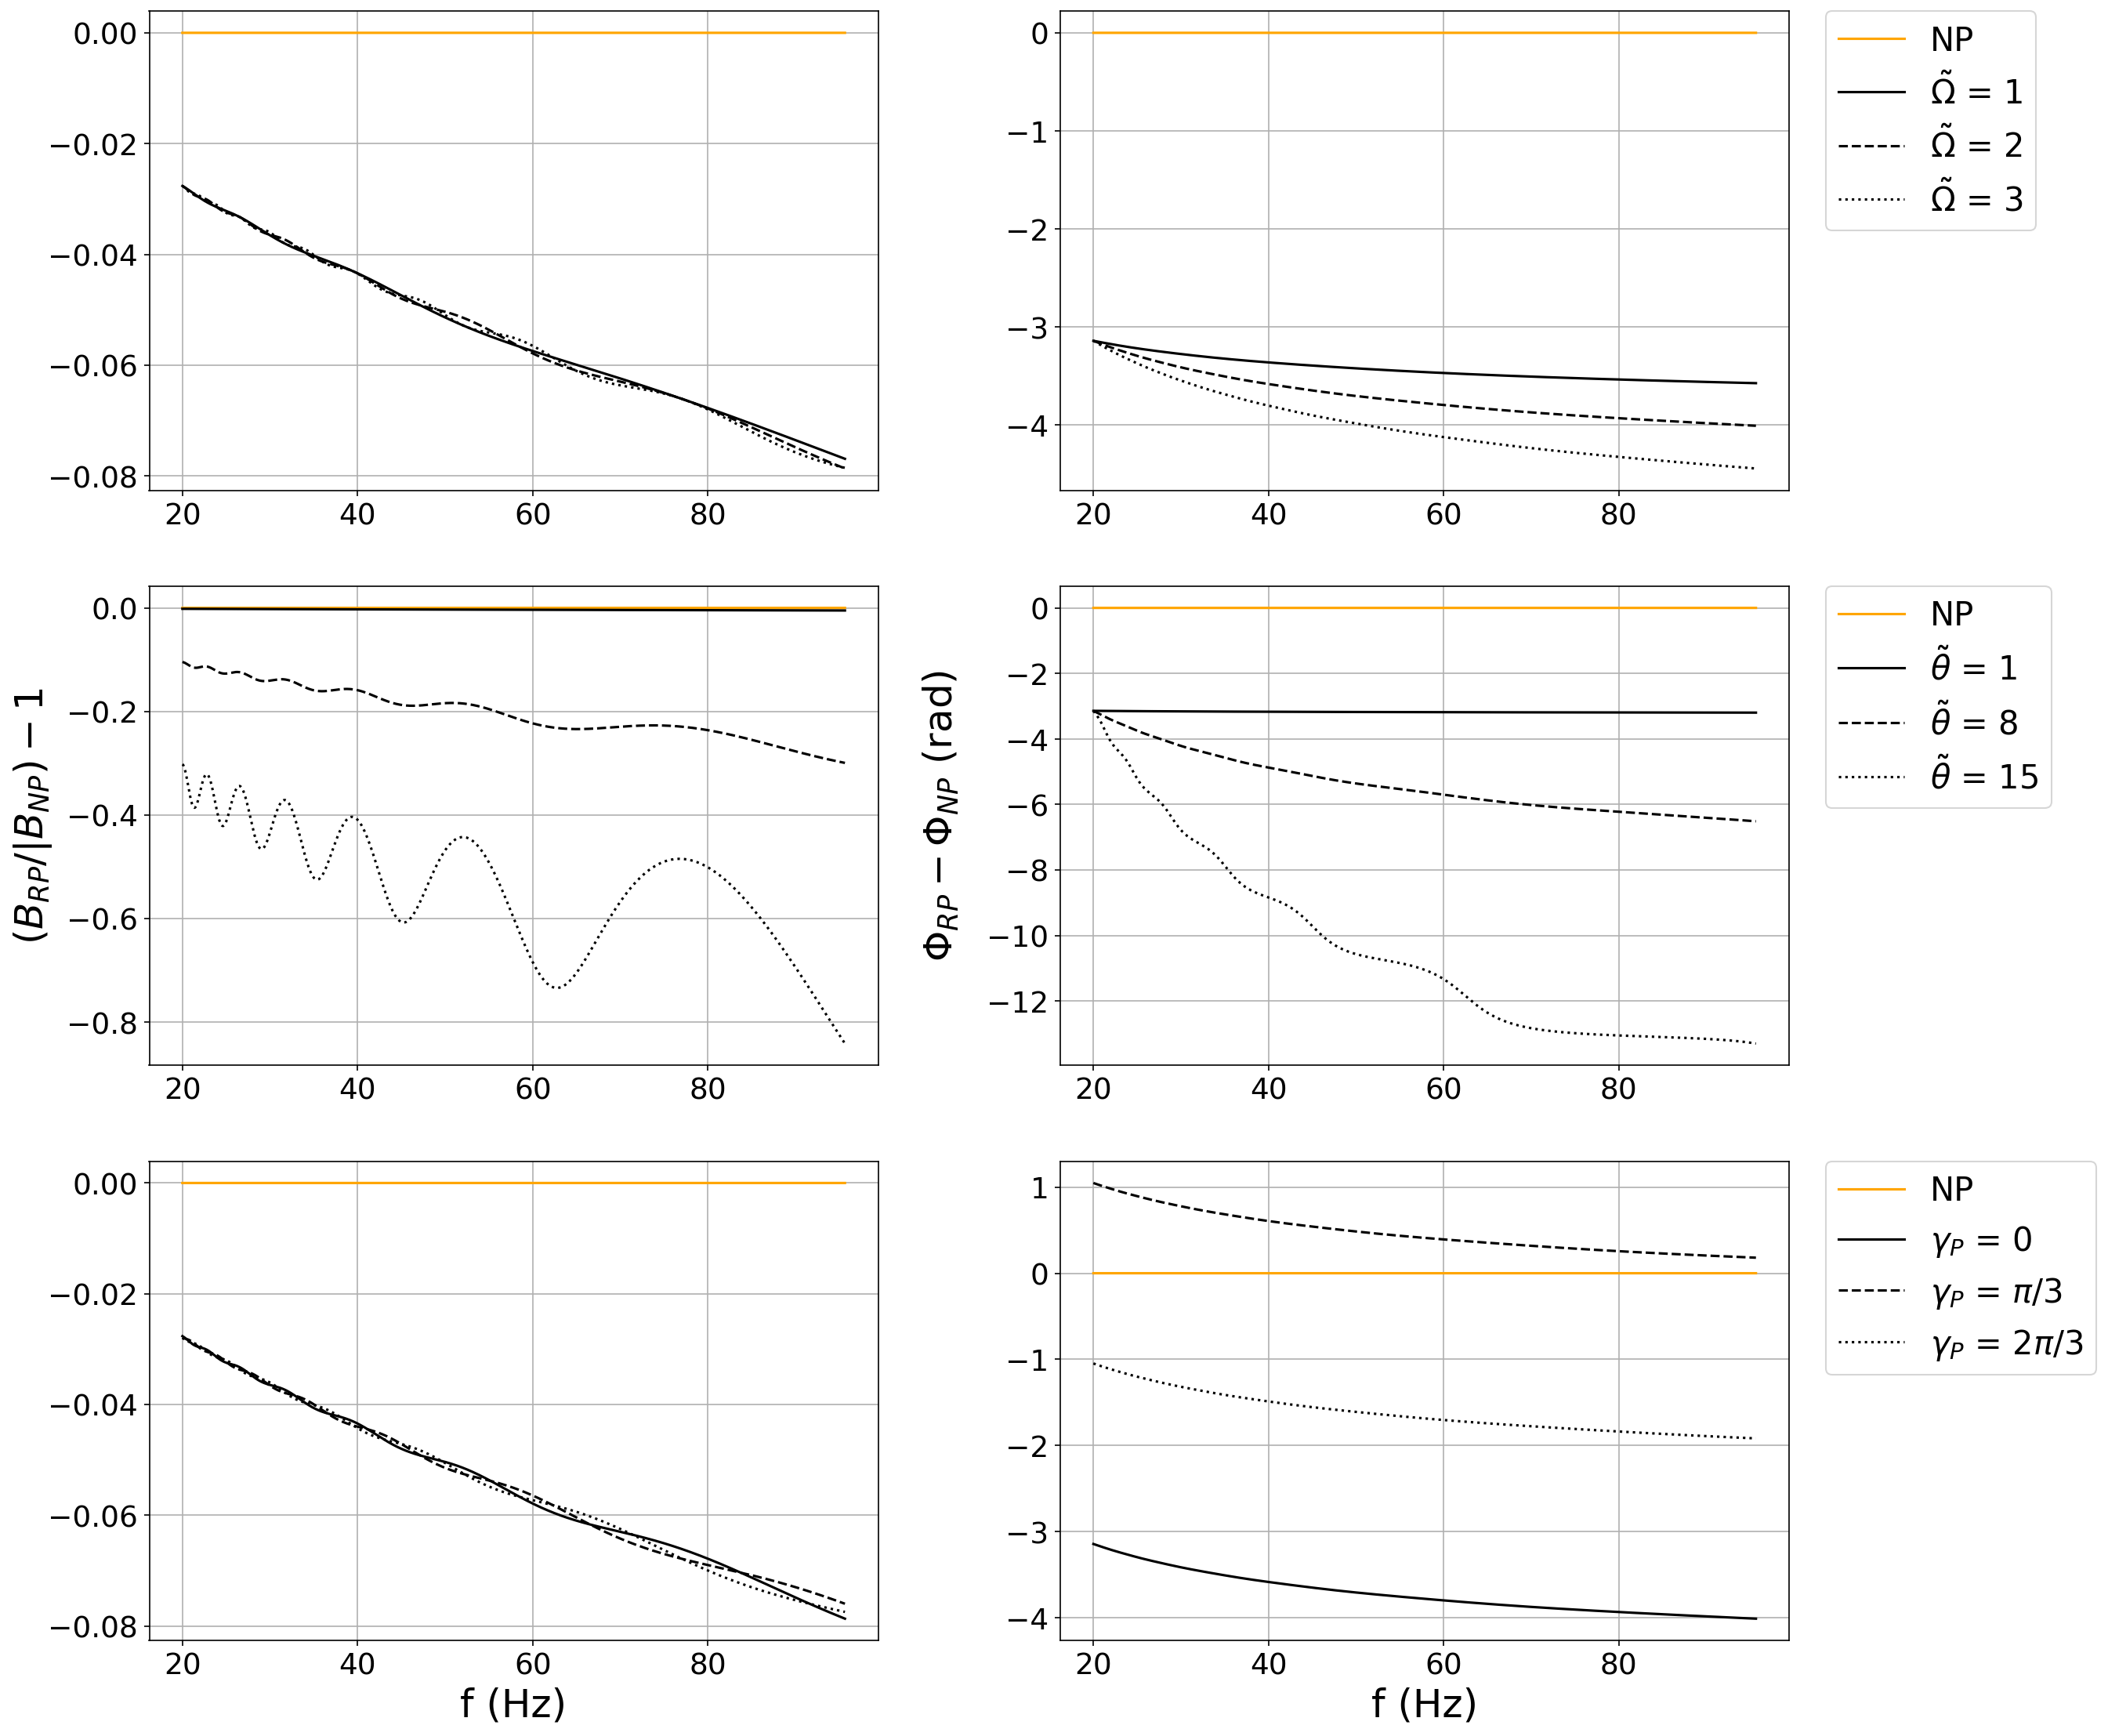

In [46]:
# Precessing (face-on): abs amplitude + phase via DRY helper
RP_params_1, NP_params_1 = set_to_location(
    loc_params["Taman"]["faceon"], RP_params_1, NP_params_1
)
fig, axes = plot_precessing_figure(
    RP_params_1,
    NP_params_1,
    theta_vals=np.array([1, 8, 15]),
    omega_vals=np.array([1, 2, 3]),
    fixed_omega=2,
    fixed_theta=4,
    amplitude_mode="ratio",
    line_styles=["-", "--", ":"],
    baseline_color="orange",
    f_min=20,
    delta_f=0.05,
)
print("system 1 in Taman's paper")